# **Automated Analysis Pipeline Notebook**
## Diabetes Prediction and Automated Analysis

**Student Name:** Meha Goyal

---

**Dataset:** Pima Indians Diabetes Database (NIH–NIDDK)

**Description:** This dataset contains diagnostic measurements from women aged 21 years or older of Pima Indian heritage. The binary prediction task is to classify whether a patient has diabetes based on the available predictor variables.

**Notebook Purpose:** Demonstrate data exploration, inferential statistics, and automated machine learning workflows, including data ingestion, missing-value handling, preprocessing, model training, and evaluation.

**Note:** This dataset is used for instructional and demonstration purposes only.

### **Assignment Description**

The purpose of the Automated Analysis Pipeline Exploration assignment is to strengthen students' understanding of how structured, reproducible, and adaptive analytical workflows are developed in health data science. Students will execute, examine, and modify a provided automated analysis pipeline to explore how foundational programming concepts, conditional logic, data exploration, and analytical decision-making work together to support automated analyses. This assignment emphasizes analytical reasoning, workflow organization, code readability, reproducibility, and the practical integration of statistical and machine learning methods within a health data science context.

Your task is to implement and execute **at least four additional examples of automated analysis code** in Google Colab beyond those provided. Examine how your workflow responds to dataset characteristics and user-defined goals. Identify the conditional logic used to automate decisions, explain the purpose of each pipeline stage, interpret the outputs (as needed), and modify selected workflow components to demonstrate how those changes affect the analysis. The links below jump to the corresponding code blocks within your copy of the notebook.

**Examples:**
1. **[Automated data ingestion](#scrollTo=OVaf3I1zyE70):** Identifies the file format and uses conditional logic to automatically select the appropriate method for reading and loading the data.

2. **Automated identification and reporting of invalid and missing values:** This process uses two consecutive blocks:
   - **[Identify known impossible values for later imputation](#scrollTo=_1r0rJ1BCX2v):** Uses a predefined list of variables to automatically replace known invalid zeros with missing values. The variable list requires knowledge of the dataset.
   - **[Automatically identify missing values in numeric predictors](#scrollTo=njK9LR0r3c7U):** Automatically identifies numeric predictors and reports their missing-value counts, including missing values created by the preceding block.

   These blocks prepare and inspect the data. Later, the machine learning pipeline fills missing predictors using medians learned from the training set and applies those same medians to the test set.

3. **[Configure and split data for the automated ML pipeline](#scrollTo=0aiR0U5sCiM-):** Uses the specified outcome variable to automatically separate predictors from the outcome, exclude rows with missing outcomes, check for numeric predictors and a binary outcome coded 0/1, and split the data into 70% training and 30% testing while preserving class proportions.

4. **[Automatically preprocess, train, and evaluate ML models](#scrollTo=l7Vt_M-pCpq0):** Automatically fills missing predictors using training-set medians, scales predictors for logistic regression, and trains logistic regression and decision tree models. Evaluates both models on the same test set, displays confusion matrices, and generates a comparison table with accuracy, recall, precision, F1, and ROC AUC scores.

In [31]:
# @title **Automated data ingestion (extended formats and encoding fallback)**

from google.colab import files
import pandas as pd
import io
from pathlib import Path

uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError("Please upload exactly one data file.")

filename = next(iter(uploaded))
extension = Path(filename).suffix.lower()
file_data = io.BytesIO(uploaded[filename])

if extension in [".csv", ".tsv", ".txt"]:
    try:
        df = pd.read_csv(file_data, sep=None, engine="python")
    except UnicodeDecodeError:
        file_data.seek(0)
        df = pd.read_csv(file_data, sep=None, engine="python", encoding="latin-1")

elif extension == ".dta":
    df = pd.read_stata(file_data)

elif extension == ".xpt":
    df = pd.read_sas(file_data, format="xport")

else:
    raise ValueError(
        f"'{extension}' is not supported. Supported formats: CSV, TSV, TXT, DTA, XPT."
    )

# Confirm that data were actually loaded.
if df.empty:
    raise ValueError("The file was read but contains no data.")

print(f"Successfully loaded: {filename}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
display(df.head())

Saving Example Dataset_Diabetes.csv to Example Dataset_Diabetes (1).csv
Successfully loaded: Example Dataset_Diabetes (1).csv
Rows: 768 | Columns: 9


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


The ingestion example automates the first stage of the pipeline by using conditional logic to decide how a file is loaded. It first checks that exactly one file was uploaded, then reads the file extension and picks the matching reader (read_csv with automatic delimiter detection for text files, read_stata for .dta, read_sas for .xpt). If a text file fails with a UnicodeDecodeError, it retries, and it stops with a clear error for unsupported formats or an empty file. This means the loading method adapts to the dataset's format, delimiter and encoding rather than relying on the user to choose one. The output (file name, row and column counts, and the first rows) confirms success. For this example extension, I added the Stata and SAS readers, the encoding fallback and the empty-data check. These make the first stage more flexible and reliable without changing the downstream analysis.

In [32]:
# @title **View first 10 rows of data**

df.head(10) # CHANGE NUMBER TO INCREASE OR DECREASE THE NUMBER OF ROWS

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [33]:
# @title **View a list of all variables**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
attribute_list = list(df.columns)
print("Variables in the dataset:")
print("")
print(attribute_list)

Variables in the dataset:

['Pregnancies', 'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']


In [34]:
# @title **View the number of rows and columns in the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
print("Number of rows and columns:")
print("")
df.shape   # (rows, columns)

Number of rows and columns:



(768, 9)

In [35]:
# @title **View general information about the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pregnancies     768 non-null    int64  
 1   Glucose         768 non-null    int64  
 2   D_BP            768 non-null    int64  
 3   Skin_Thickness  768 non-null    int64  
 4   Insulin         768 non-null    int64  
 5   BMI             768 non-null    float64
 6   Pedigree        768 non-null    float64
 7   Age             768 non-null    int64  
 8   Outcome         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
# @title **Describe the data (and data type) for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Describe all columns
summary = df.describe(include='all').T

# Replace NaN values with 'NA'
summary = summary.fillna('NA')

# Insert formatted variable name + data type
summary.insert(
    0,
    'Variable',
    [f"<b>{col}</b><br><span style='font-weight:normal; font-size:smaller;'>[{df[col].dtype}]</span>" for col in summary.index]
)

# Reset index to clean up formatting
summary.reset_index(drop=True, inplace=True)

# Format numeric columns to 3 decimal places only
styled_summary = (
    summary.style
    .format(precision=3, na_rep="NA")  # Format numbers to 3 decimals
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis='index')  # Remove default row index
)

styled_summary

Variable,count,mean,std,min,25%,50%,75%,max
Pregnancies[int64],768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose[int64],768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
D_BP[int64],768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
Skin_Thickness[int64],768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin[int64],768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI[float64],768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
Pedigree[float64],768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age[int64],768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome[int64],768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [37]:
# @title **Automatically replace impossible zeros and report missing values**

import numpy as np
import pandas as pd

target_variable = "Outcome"
zeros_allowed = ["Pregnancies"]   # CHANGE: variables where 0 is a valid value
max_missing_share = 0.40          # CHANGE: share of missing values that triggers a warning

df_checked = df.copy()
numeric_cols = df_checked.select_dtypes(include="number").columns.drop(target_variable, errors="ignore")

# Replace zeros with missing values, except in variables where 0 is valid.
for col in numeric_cols:
    if col in zeros_allowed:
        continue
    zero_count = (df_checked[col] == 0).sum()
    if zero_count > 0:
        df_checked[col] = df_checked[col].replace(0, np.nan)
        print(f"{col}: {zero_count} zeros replaced with missing values")


Glucose: 5 zeros replaced with missing values
D_BP: 35 zeros replaced with missing values
Skin_Thickness: 227 zeros replaced with missing values
Insulin: 374 zeros replaced with missing values
BMI: 11 zeros replaced with missing values


In [38]:
# @title **Automatically identify other missing values in numeric predictors**

target_variable = "Outcome"

# Automatically identify numeric predictors.
numeric_predictors = df.select_dtypes(include="number").columns
numeric_predictors = numeric_predictors.drop(
    target_variable, errors="ignore"
)

# Count missing values.
missing_counts = df[numeric_predictors].isna().sum()
predictors_with_missing = missing_counts[missing_counts > 0]

for col, share in missing_share.items():
    if share > max_missing_share:
        print(f"WARNING: {col} is {share:.1%} missing; consider excluding it.")

if predictors_with_missing.empty:
    print("No missing values detected in numeric predictors.")
else:
    print("Predictors requiring imputation:")
    display(predictors_with_missing.rename("Missing values").to_frame())
    print("Block #4 will automatically fill these using training-set medians.")

No missing values detected in numeric predictors.


Instead of the original code's hard-coded list of variables that need zero replacement, my new version checks every numeric predictor. It replaces zeros with missing values unless the variable is on a short list where zero is valid (like Pregnancies). It works on a copy (df_checked), so the original df is untouched. On the Pima data it replaced zeros in Glucose (5), D_BP (35), Skin_Thickness (227), Insulin (374) and BMI (11), matching the original pipeline. It warned only for Insulin (48.7% missing), since Skin_Thickness (29.6%) is below the 40% cutoff.

In [39]:
# @title **Description of just one variable**

# Define the variable name (this can be dynamic)
variable = 'BMI'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {variable}:")
print("")

# Get the description and round it to 3 decimal places
description = df[variable].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of BMI:

count    768.000
mean      31.993
std        7.884
min        0.000
25%       27.300
50%       32.000
75%       36.600
max       67.100
Name: BMI, dtype: float64


In [40]:
# @title **Number of responses and missing values for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Count non-null and missing responses
response_counts = df.count()
missing_counts = df.isnull().sum()

# Combine into one DataFrame
df_count = pd.DataFrame({
    'Variable': response_counts.index,
    '# of Responses': response_counts.values,
    '# Missing': missing_counts.values
})

# Display as styled table: bold headers and center-aligned values
df_count.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,# of Responses,# Missing
0,Pregnancies,768,0
1,Glucose,768,0
2,D_BP,768,0
3,Skin_Thickness,768,0
4,Insulin,768,0
5,BMI,768,0
6,Pedigree,768,0
7,Age,768,0
8,Outcome,768,0


In [41]:
# @title **View 15 random rows of data**
np.random.seed()
df.sample(n=15) # CHANGE NUMBER HERE TO INCREASE OR DECREASE NUMBER OF RANDOM ROWS

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
173,1,79,60,42,48,43.5,0.678,23,0
112,1,89,76,34,37,31.2,0.192,23,0
514,3,99,54,19,86,25.6,0.154,24,0
49,7,105,0,0,0,0.0,0.305,24,0
667,10,111,70,27,0,27.5,0.141,40,1
76,7,62,78,0,0,32.6,0.391,41,0
741,3,102,44,20,94,30.8,0.400,26,0
168,4,110,66,0,0,31.9,0.471,29,0
249,1,111,86,19,0,30.1,0.143,23,0
203,2,99,70,16,44,20.4,0.235,27,0


In [42]:
# @title **Change a variable's data type (e.g., from integer to category)**

# Choose variable to change
variable_to_change = 'Outcome' # CHANGE THIS VARIABLE
new_data_type = 'category' # CHANGE THIS TO THE NEW DATA TYPE (options include category, int64, float)

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
# Capture original data type
original_dtype = df[variable_to_change].dtype

# Change data type (options include category, float, int64)
df[variable_to_change] = df[variable_to_change].astype(new_data_type)

# Capture new data type
new_dtype = df[variable_to_change].dtype

# Print result dynamically
print(f"'{variable_to_change}' variable changed from {original_dtype} to {new_dtype}")
print("")
print("Note: You can revise the code to change the data type for a different variable.")

'Outcome' variable changed from int64 to category

Note: You can revise the code to change the data type for a different variable.


## **Exploratory Data Analysis**

In [43]:
# @title **Pearson's correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
D_BP,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
Skin_Thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
Pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


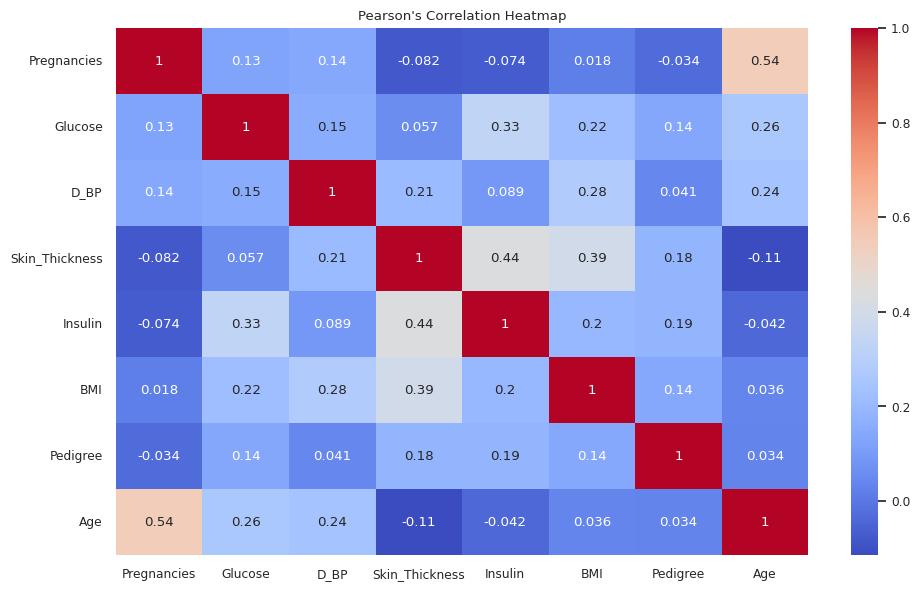

In [44]:
# @title **Pearson's correlation heatmap**

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson's Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
# @title **Spearman's Rank correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.corr(method='spearman')

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.000000,0.130734,0.185127,-0.085222,-0.126723,0.000132,-0.043242,0.607216,0.198689
Glucose,0.130734,1.000000,0.235191,0.060022,0.213206,0.231141,0.091293,0.285045,0.475776
D_BP,0.185127,0.235191,1.000000,0.126486,-0.006771,0.292870,0.030046,0.350895,0.142921
Skin_Thickness,-0.085222,0.060022,0.126486,1.000000,0.541000,0.443615,0.180390,-0.066795,0.089728
Insulin,-0.126723,0.213206,-0.006771,0.541000,1.000000,0.192726,0.221150,-0.114213,0.066472
BMI,0.000132,0.231141,0.292870,0.443615,0.192726,1.000000,0.141192,0.131186,0.309707
Pedigree,-0.043242,0.091293,0.030046,0.180390,0.221150,0.141192,1.000000,0.042909,0.175353
Age,0.607216,0.285045,0.350895,-0.066795,-0.114213,0.131186,0.042909,1.000000,0.309040
Outcome,0.198689,0.475776,0.142921,0.089728,0.066472,0.309707,0.175353,0.309040,1.000000


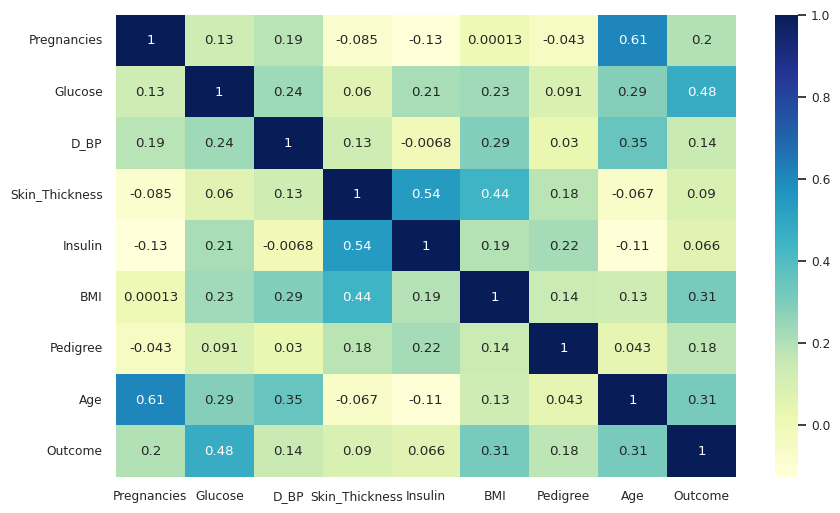

In [46]:
# @title **Spearman's Rank correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5
sns.heatmap(df.corr(method='spearman'), annot=True, cmap="YlGnBu");

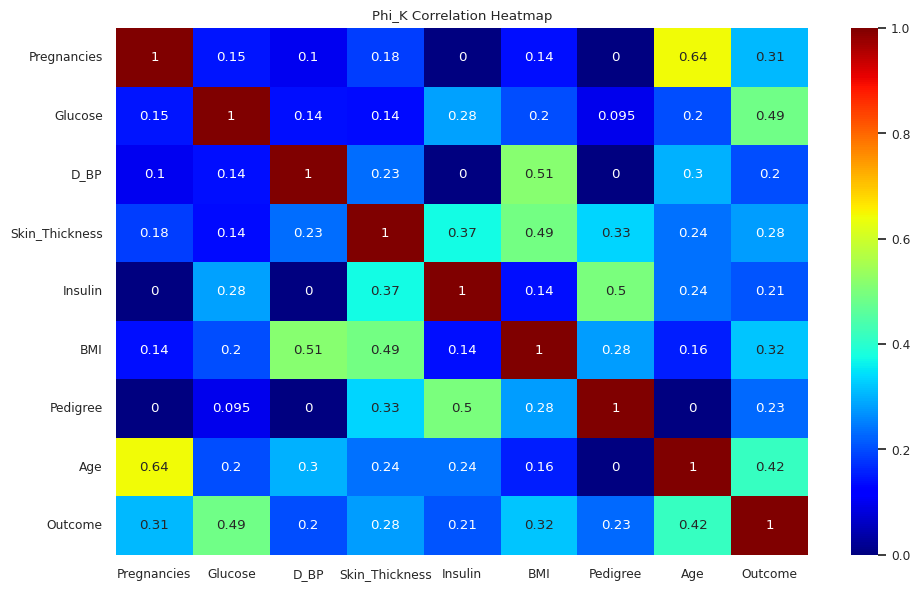

In [47]:
# @title **Phi-K correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

import os
import sys
import subprocess

# Suppress pip install output
subprocess.run([sys.executable, "-m", "pip", "install", "phik"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import phik
from phik import resources, report
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Identify interval (numerical) columns
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create correlation map using Phi-K
plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

# Compute and plot Phi-K correlation matrix with interval columns specified
phik_corr = df.phik_matrix(interval_cols=interval_cols)
sns.heatmap(phik_corr, annot=True, cmap="jet")

plt.title("Phi_K Correlation Heatmap")
plt.tight_layout()
plt.show()

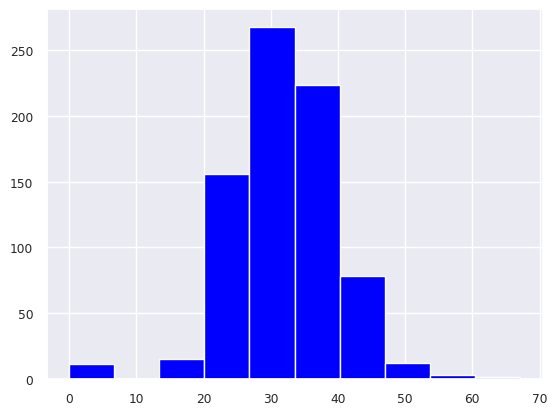

In [48]:
# @title **Example of a histogram**
plt.hist(df['BMI'], color='blue'); # CHANGE VARIABLE HERE

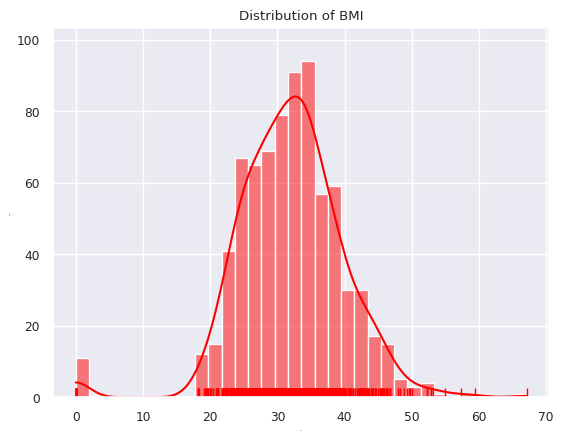

In [49]:
# @title **Example of a distribution plot**

import seaborn as sns
import matplotlib.pyplot as plt

variable = "BMI"

sns.histplot(data=df, x=variable, color="red", kde=True)
sns.rugplot(data=df, x=variable, color="red")

plt.title(f"Distribution of {variable}")
plt.show()

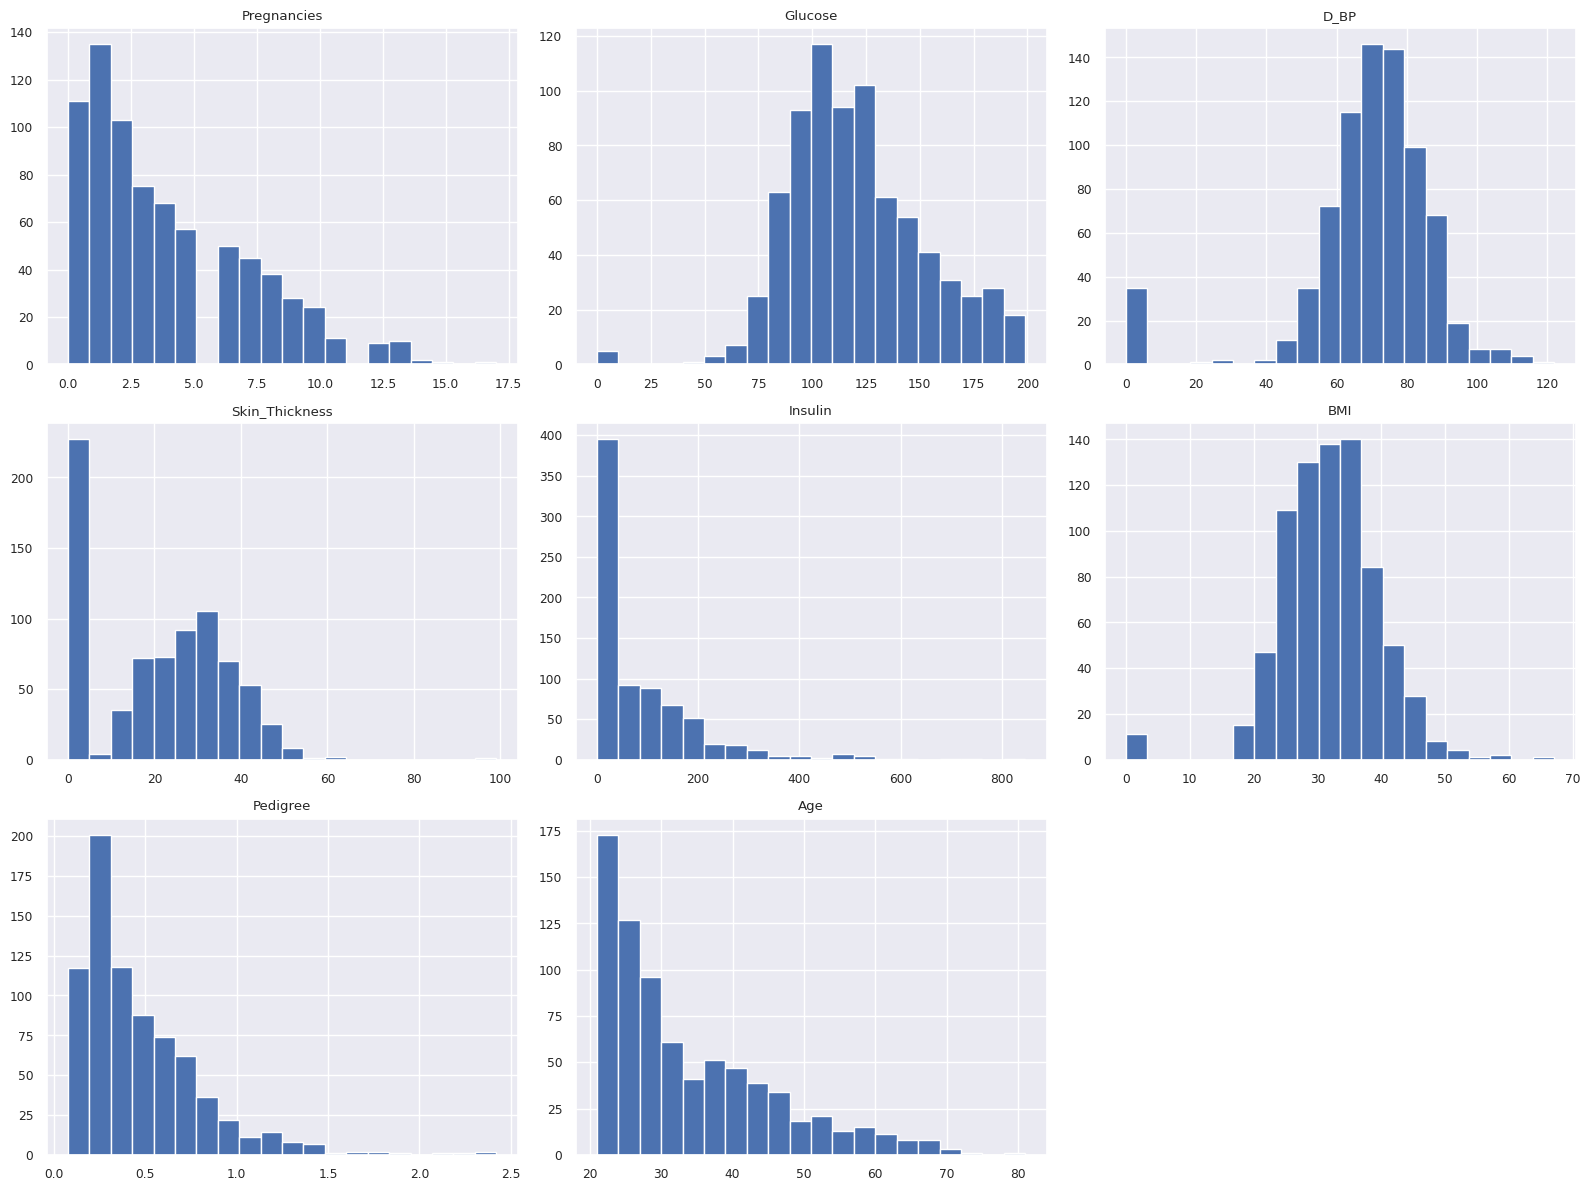

In [50]:
# @title **Generate histograms for all numerical variables**
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

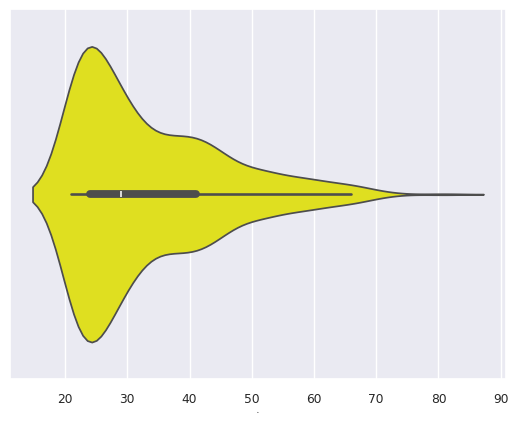

In [51]:
# @title **Example of a violin plot**
sns.violinplot(df['Age'], color='yellow', orient='h'); # CHANGE VARIABLE AND COLOR HERE

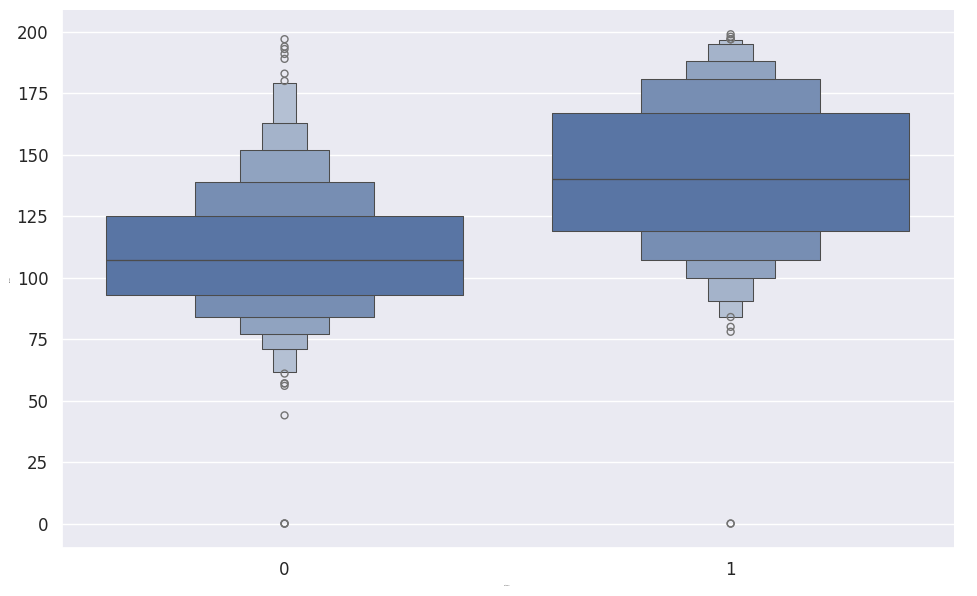

In [52]:
# @title **Example of categorical plot**
# Define the plot variables
x_var = "Outcome"
y_var = "Glucose"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the plot
g = sns.catplot(x=x_var, y=y_var, data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);

# Dynamically set axis labels
g.set_axis_labels(x_var, y_var)
g.set_titles("{col_name}")

# Optionally set font size
g.set(xlabel=x_var, ylabel=y_var)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [53]:
# @title **Define a function to create a boxplot and histogram combo**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
def histogram_boxplot(feature, figsize=(10,6), bins=None):
    """ Boxplot and histogram combined (horizontal boxplot version)
    feature: 1-d feature array
    figsize: size of fig (default (10,6))
    bins: number of bins (default None / auto)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import norm

    sns.set(font_scale=1)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Horizontal boxplot
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')

    # Histogram
    if bins:
        sns.histplot(feature, kde=False, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(feature, kde=False, ax=ax_hist2)

    # Add central tendency lines to histogram
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='green', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='red', linestyle='dashed', linewidth=1, label='Mode')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

print("Function successfully created")

Function successfully created


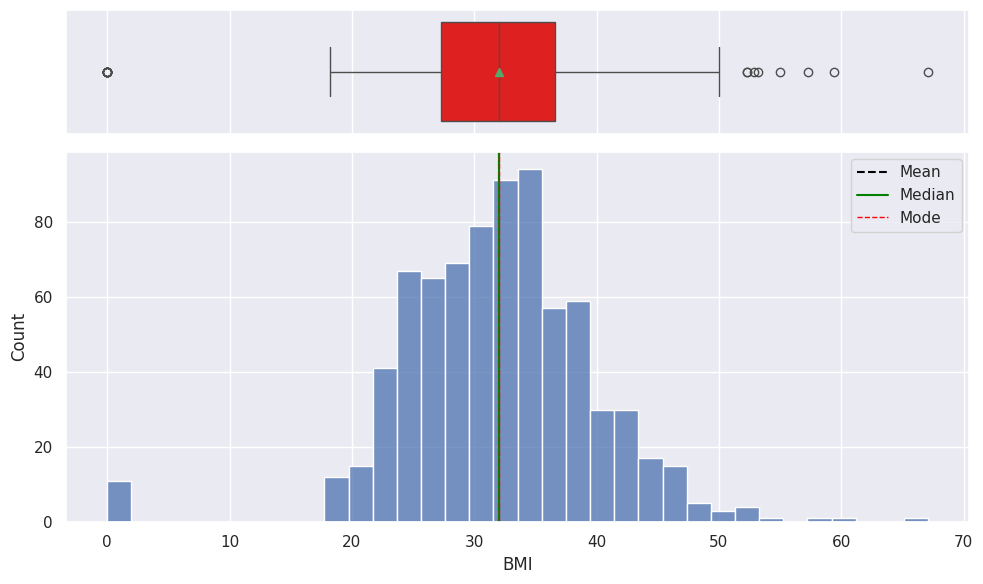

In [54]:
# @title **Example of a combination boxplot and histogram**

histogram_boxplot(df.BMI) # CHANGE THE CONTINUOUS VARIABLE HERE

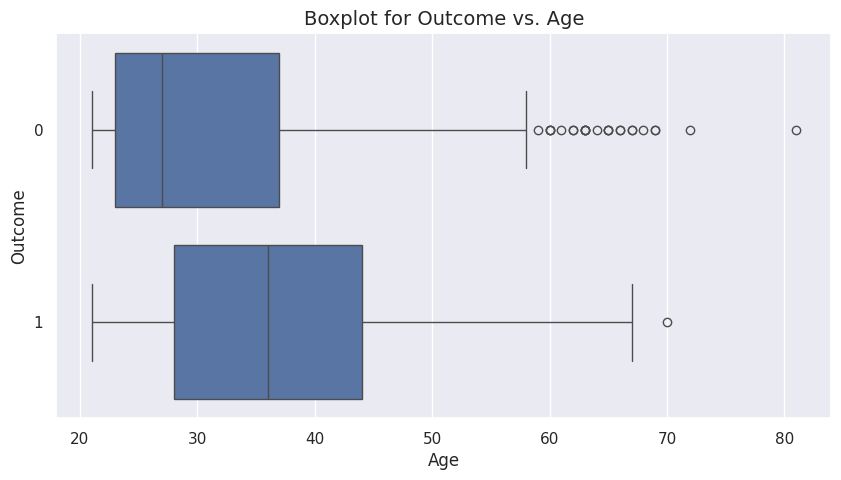

In [55]:
# @title **Example of boxplot with the primary outcome and a continuous variable**

# Define variables
x_var = "Age" # CHANGE VARIABLE HERE
y_var = "Outcome"  # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=x_var, y=y_var, data=df)

# Dynamic labels and title
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'Boxplot for {y_var} vs. {x_var}', fontsize=14)

plt.show()

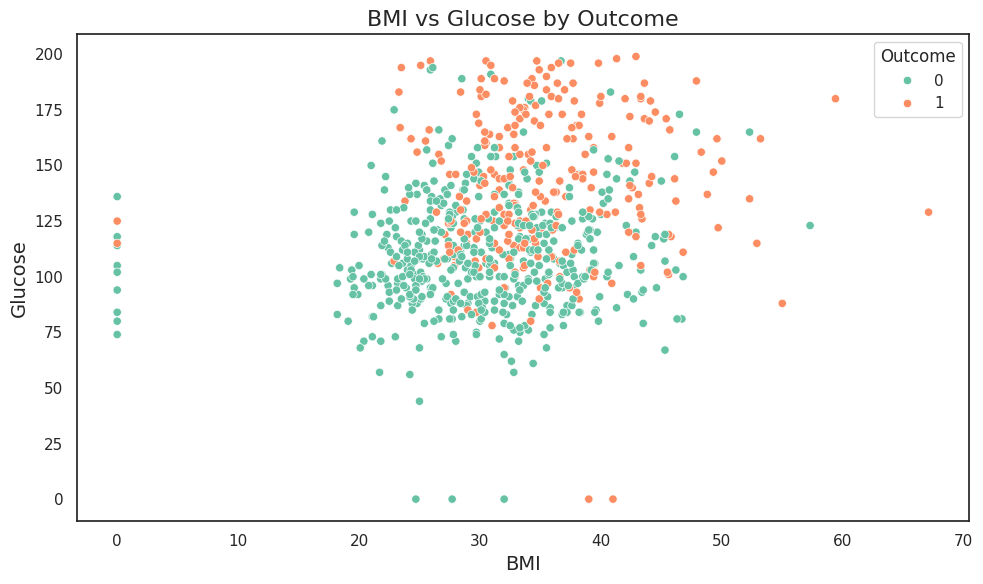

In [56]:
# @title **Example of a scatterplot**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the scatterplot
sns.set(style="white")  # Clean background without gridlines
plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(x='BMI', y='Glucose', hue='Outcome', data=df, palette='Set2')

# Add title and axis labels
plt.title('BMI vs Glucose by Outcome', fontsize=16)
plt.xlabel('BMI', fontsize=14)
plt.ylabel('Glucose', fontsize=14)

# Remove gridlines
plt.grid(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

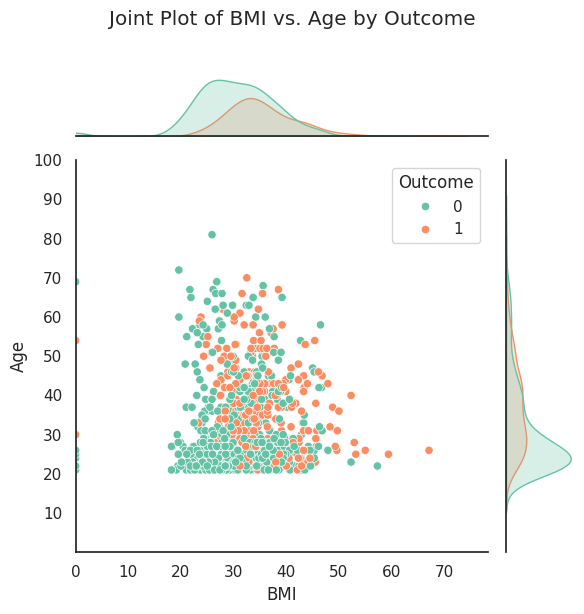

In [57]:
# @title **Example of a joint plot (3 variables)**
g = sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE
    hue='Outcome',
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g.ax_joint.set_xlim(left=0)
g.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g.ax_joint.get_ylim()
g.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle("Joint Plot of BMI vs. Age by Outcome", y=1.02)
plt.tight_layout()
plt.show()

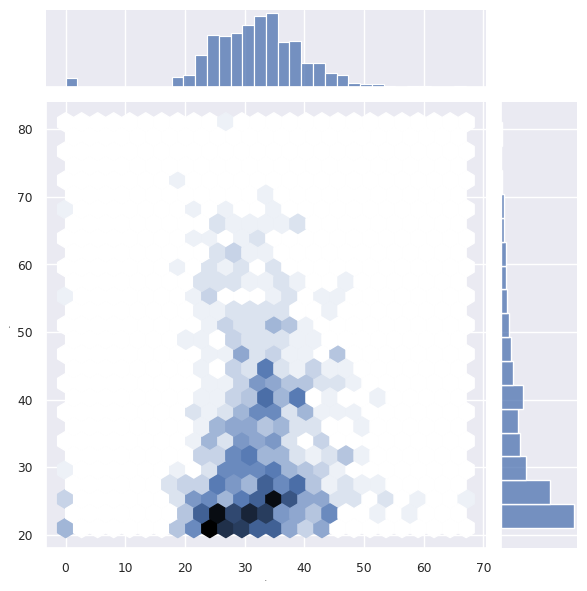

In [58]:
# @title **Example of a joint plot of a different kind (2 variables)**

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='hex',
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

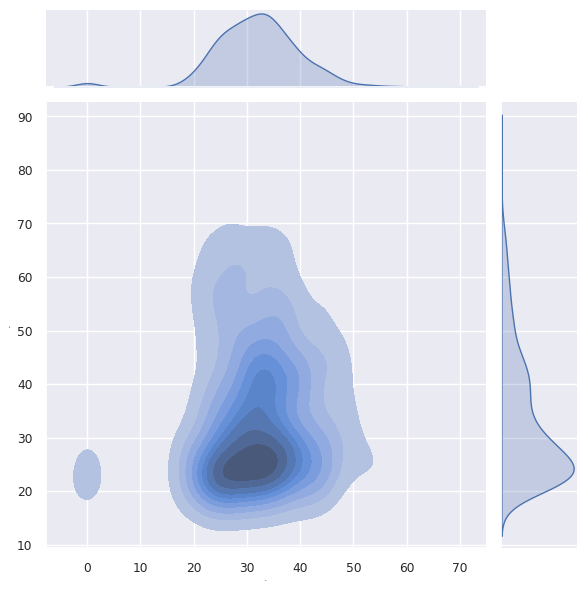

In [59]:
# @title **Another example of a joint plot of a different kind (2 variables)**
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)
plt.rcParams["axes.labelsize"] = 0.5

sns.jointplot(
    x='BMI', # CHANGE VARIABLE HERE
    y='Age', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='kde',
    fill = True,
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

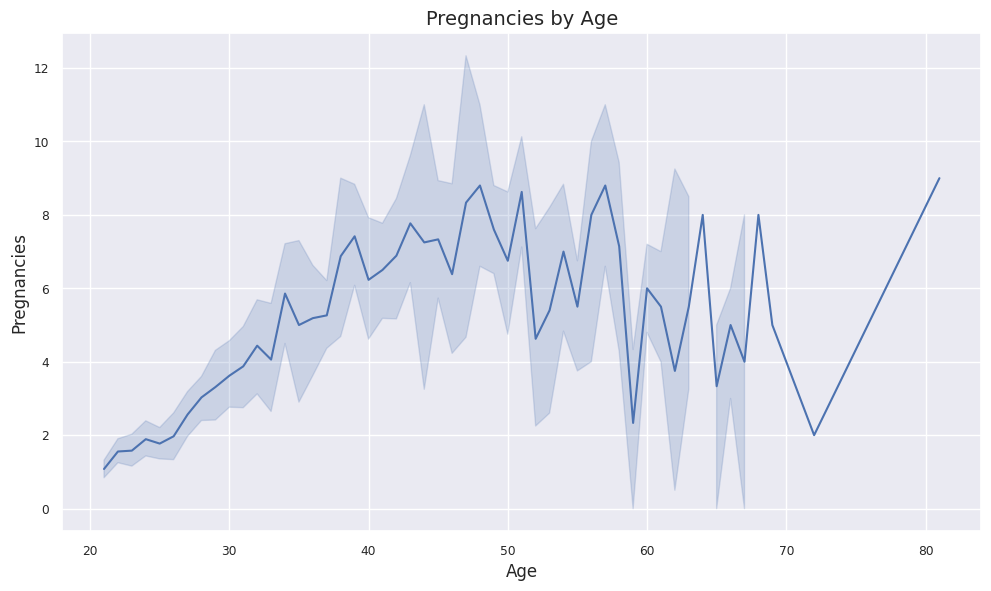

In [60]:
# @title **Example of a line plot**

# Define x and y columns
x_col = 'Age' # CHANGE VARIABLE HERE
y_col = 'Pregnancies' # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lineplot
sns.lineplot(x=x_col, y=y_col, data=df, ax=ax)

# Set axis labels and title explicitly
ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f'{y_col} by {x_col}', fontsize=14)

# Ensure labels are not cut off
plt.tight_layout()

# Show the plot
plt.show()

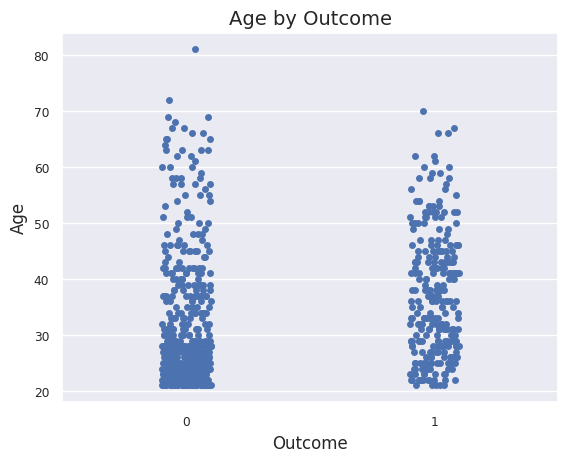

In [61]:
# @title **Example of a strip plot**

# Define axis variables
x_var = "Outcome"  # CHANGE VARIABLE HERE
y_var = "Age"      # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
sns.stripplot(data=df, x=x_var, y=y_var, jitter=True)
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

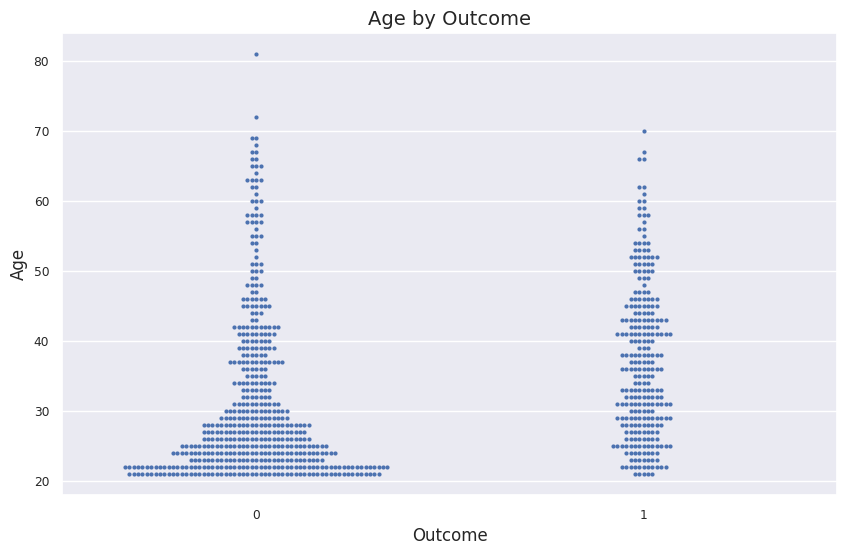

In [62]:
# @title **Example of a swarm plot**

x_var = "Outcome"
y_var = "Age"

plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x=x_var, y=y_var, size=3)

plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

**Link to other data visualizations: https://seaborn.pydata.org/examples/index.html**

## **Inferential Statistics**

In [63]:
# @title **Import additional inferential statistics libraries**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

print("Libraries successfully imported.")

Libraries successfully imported.


In [64]:
# @title **Example of a one-sample t-test**

from scipy.stats import ttest_1samp

variable = "BMI"       # CHANGE VARIABLE HERE
threshold = 30        # CHANGE REFERENCE VALUE HERE
alpha = 0.05          # CHANGE SIGNIFICANCE LEVEL HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing observations.
values = df[variable].dropna()

if len(values) < 2 or values.std() == 0:
    raise ValueError(
        "The test requires at least two nonmissing values and nonzero variance."
    )

# Perform a two-sided one-sample t-test.
t_statistic, p_value = ttest_1samp(values, popmean=threshold)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"is {direction} than {threshold}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence that the population mean "
        f"{variable} differs from {threshold}."
    )

print(f"Null hypothesis: The population mean {variable} equals {threshold}.")
print(f"Alternative hypothesis: The population mean {variable} differs from {threshold}.")
print(f"\nNonmissing observations: {len(values)}")
print(f"Sample mean: {values.mean():.3f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean BMI equals 30.
Alternative hypothesis: The population mean BMI differs from 30.

Nonmissing observations: 768
Sample mean: 31.993
t-statistic: 7.004
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean BMI is higher than 30.


In [65]:
# @title **Independent samples t-test (specific to this dataset)**

from scipy.stats import ttest_ind

variable = "BMI"
group_col = "Outcome"
alpha = 0.05

label_map = {0: "Patients without diabetes", 1: "Patients with diabetes"}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing either the measurement or group.
test_data = df[[variable, group_col]].dropna()

if set(test_data[group_col].unique()) != {0, 1}:
    raise ValueError("The group variable must contain both groups, coded 0 and 1.")

# Set a consistent comparison order.
group1 = test_data.loc[test_data[group_col] == 0, variable]
group2 = test_data.loc[test_data[group_col] == 1, variable]

if len(group1) < 2 or len(group2) < 2:
    raise ValueError("Each group requires at least two nonmissing observations.")

if group1.var() == 0 and group2.var() == 0:
    raise ValueError("The test requires variation in at least one group.")

group1_name = label_map[0]
group2_name = label_map[1]

# Two-sided Welch's t-test.
t_statistic, p_value = ttest_ind(group1, group2, equal_var=False)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"for {group1_name.lower()} is {direction} than "
        f"for {group2_name.lower()}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference in population "
        f"mean {variable} between the two groups."
    )

print(f"Null hypothesis: The population mean {variable} is equal between groups.")
print(f"Alternative hypothesis: The population mean {variable} differs between groups.")

print(f"\n{group1_name}: n = {len(group1)}, mean = {group1.mean():.3f}")
print(f"{group2_name}: n = {len(group2)}, mean = {group2.mean():.3f}")
print(f"Mean difference (group 0 − group 1): {group1.mean() - group2.mean():.3f}")

print(f"\nWelch's independent samples t-test:")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean BMI is equal between groups.
Alternative hypothesis: The population mean BMI differs between groups.

Patients without diabetes: n = 500, mean = 30.304
Patients with diabetes: n = 268, mean = 35.143
Mean difference (group 0 − group 1): -4.838

Welch's independent samples t-test:
t-statistic: -8.619
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean BMI for patients without diabetes is lower than for patients with diabetes.


In [66]:
# @title **One-way ANOVA (specific to this dataset)**

import statsmodels.api as sm
from statsmodels.formula.api import ols

variable = "Glucose"
group_col = "Outcome"
alpha = 0.05

label_map = {
    0: "Patients without diabetes",
    1: "Patients with diabetes"
}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing the measurement or group.
test_data = df[[variable, group_col]].dropna().copy()

# Use standard column names for the model formula.
test_data.columns = ["measurement", "group"]
test_data["group"] = test_data["group"].astype("category")
test_data["group"] = test_data["group"].cat.remove_unused_categories()

group_summary = (
    test_data.groupby("group", observed=True)["measurement"]
    .agg(["count", "mean", "std"])
)

if len(group_summary) < 2:
    raise ValueError("ANOVA requires at least two groups.")

if (group_summary["count"] < 2).any():
    raise ValueError("Each group requires at least two nonmissing observations.")

if (group_summary["std"] == 0).all():
    raise ValueError("The test requires variation within at least one group.")

# Fit the model and calculate the ANOVA table.
anova_model = ols("measurement ~ C(group)", data=test_data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

f_stat = anova_table.loc["C(group)", "F"]
p_value = anova_table.loc["C(group)", "PR(>F)"]

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    interpretation = (
        f"There is evidence that at least two groups differ "
        f"in population mean {variable}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference "
        f"in population mean {variable} across groups."
    )

# Apply readable group labels for display.
group_summary.index = [
    label_map.get(group, str(group))
    for group in group_summary.index
]

print(f"Null hypothesis: Population mean {variable} is equal across all groups.")
print(f"Alternative hypothesis: At least one population mean differs.")

print("\nGroup summaries:")
display(group_summary.round(3))

print("\nANOVA table:")
display(anova_table.round(3))

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: Population mean Glucose is equal across all groups.
Alternative hypothesis: At least one population mean differs.

Group summaries:


,count,mean,std
Patients without diabetes,500,109.980,26.141
Patients with diabetes,268,141.257,31.940



ANOVA table:


,sum_sq,df,F,PR(>F)
C(group),170689.422,1.0,213.162,0.0
Residual,613375.035,766.0,NaN,NaN



F-statistic: 213.162
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that at least two groups differ in population mean Glucose.


In [67]:
# @title **Chi-square test of independence (specific to this dataset)**

import pandas as pd
from scipy.stats import chi2_contingency

group_col = "Outcome"
variable = "Pregnancies"
threshold = 10
alpha = 0.05

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing values before creating categories.
test_data = df[[group_col, variable]].dropna().copy()
test_data["Above threshold"] = test_data[variable] > threshold

crosstab = pd.crosstab(
    test_data[group_col],
    test_data["Above threshold"]
)

if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
    raise ValueError("The test requires at least two observed categories per variable.")

# Run Pearson's chi-square test without continuity correction.
chi2_stat, p_value, dof, expected = chi2_contingency(
    crosstab, correction=False
)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

print("Observed counts (False = ≤ threshold; True = > threshold):")
display(crosstab)

print("\nExpected counts under independence:")
display(pd.DataFrame(
    expected,
    index=crosstab.index,
    columns=crosstab.columns
).round(3))

print(f"\nNull hypothesis: {group_col} and {variable} > {threshold} are independent.")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p {formatted_p}")

if (expected < 5).any():
    print(
        "\nSmall expected counts detected. For this 2×2 table, "
        "consider Fisher's exact test before interpreting the chi-square result."
    )

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        f"Interpretation: There is evidence of an association between "
        f"{group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        f"Interpretation: There is insufficient evidence of an association "
        f"between {group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )

Observed counts (False = ≤ threshold; True = > threshold):


Above threshold,False,True
Outcome,,
0,486,14
1,248,20



Expected counts under independence:


Above threshold,False,True
Outcome,,
0,477.865,22.135
1,256.135,11.865



Null hypothesis: Outcome and Pregnancies > 10 are independent.
Chi-square statistic: 8.965
Degrees of freedom: 1
p = 0.003
Decision: Reject the null hypothesis.
Interpretation: There is evidence of an association between Outcome and having Pregnancies > 10, provided the test assumptions are met.


In [68]:
# @title **Encode outcome labels as 0 and 1 (if needed)**

target_variable = "Outcome"
label_map = {"No Diabetes": 0, "Diabetes": 1}

outcome = df[target_variable]
observed_values = set(outcome.dropna().unique())

if observed_values.issubset({0, 1}):
    print("Outcome is already coded as 0/1.")

elif observed_values.issubset(set(label_map)):
    df[target_variable] = outcome.map(label_map)
    print("Outcome labels converted to 0/1.")

else:
    raise ValueError(
        f"Unexpected outcome values: {observed_values}. "
        "Update label_map to match your dataset."
    )

display(df[target_variable].head(10))

Outcome is already coded as 0/1.


,Outcome
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,0
8,1
9,1


## **Supervised Machine Learning (Binary Classification)**

**Two examples:**
- Logistic Regression  
- Decision Tree  

**LOGISTIC REGRESSION:** Additional Info on Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## **Logistic Regression**

In [69]:
# @title **Configure and split data for the automated ML pipeline**

from sklearn.model_selection import train_test_split

target_variable = "Outcome"  # CHANGE FOR YOUR DATASET

# Exclude rows with missing outcomes; do not impute the outcome.
ml_data = df.dropna(subset=[target_variable]).copy()

X = ml_data.drop(columns=[target_variable])
y = ml_data[target_variable]

# This demonstration expects numeric predictors and an outcome coded 0/1.
if set(y.unique()) != {0, 1}:
    raise ValueError("The outcome must contain both classes, coded 0 and 1.")

if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
    raise ValueError("This pipeline requires numeric predictors.")

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")


# Smaller datasets keep more data for testing.
test_size = 0.20 if len(ml_data) >= 1000 else 0.30

# Stratify only when the smallest class is large enough.
stratify = y if y.value_counts().min() >= 10 else None

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=stratify)

print(f"Test size used: {test_size:.0%}")
print("Training class proportions:\n", y_tr.value_counts(normalize=True).round(3))
print("Test class proportions:\n", y_te.value_counts(normalize=True).round(3))

Training observations: 537
Test observations: 231
Test size used: 30%
Training class proportions:
 Outcome
0    0.652
1    0.348
Name: proportion, dtype: float64
Test class proportions:
 Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


For this extension, I add a split choice based on the data. The original split always uses 70/30 with stratification. This version makes both choices depend on the data, where the test share is 30% for datasets under 1,000 rows and 20% for larger ones, and stratification is used only when the smallest class has at least 10 observations. The Pima data has 768 rows, so it used a 30% test set, the same as the original. The printed class proportions show the split preserved the class balance: 34.8% diabetes in training and 35.1% in the test set. I named the split variables X_tr, X_te, y_tr and y_te, so they don't overwrite the original X_train and X_test.

In [70]:
# @title **Define a function to display a confusion matrix**

from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_actual, y_predict):
    """Display counts and percentages of all evaluated observations."""

    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    if cm.sum() == 0:
        raise ValueError("No observations with labels 0 or 1 to display.")

    cell_names = np.array([
        ["True negative", "False positive"],
        ["False negative", "True positive"]
    ])

    annotations = np.array([
        f"{name}\n{count}\n{count / cm.sum():.2%}"
        for name, count in zip(cell_names.flatten(), cm.flatten())
    ]).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

print("Function successfully created.")

Function successfully created.


In [71]:
# @title **Build logistic regression with automated preprocessing**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Learn imputation and scaling from training data only.
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Apply the fitted preprocessing and model to test data.
y_predict = logistic_pipeline.predict(X_test)
model_score = logistic_pipeline.score(X_test, y_test)

print(f"Test-set accuracy: {model_score:.2%}")
print(
    f"The model correctly classified {model_score:.2%} "
    "of observations in the test set."
)

Test-set accuracy: 74.46%
The model correctly classified 74.46% of observations in the test set.


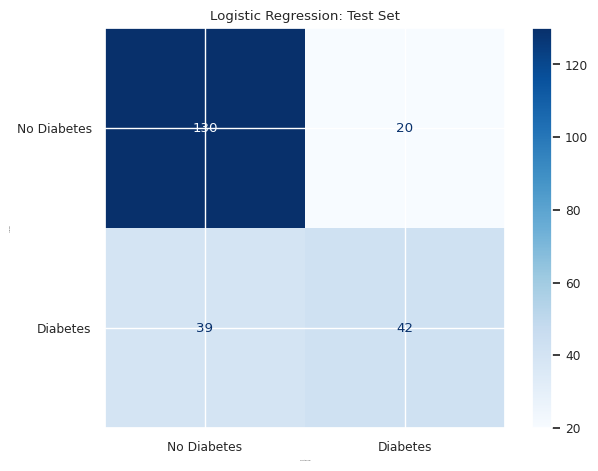

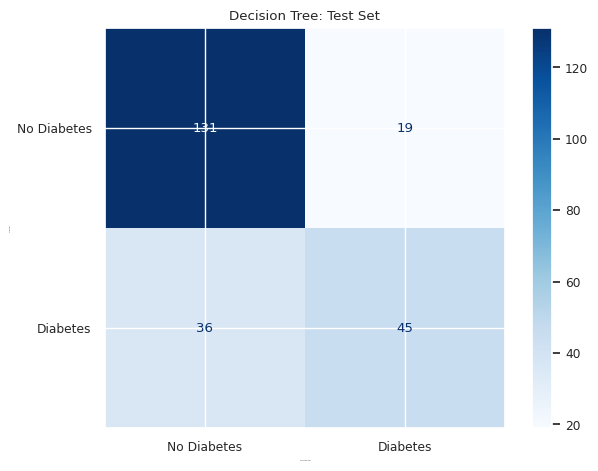

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC
Model,,,,,
Logistic Regression,0.745,0.519,0.677,0.587,0.838
Decision Tree,0.762,0.556,0.703,0.621,0.714


In [72]:
# @title **Automatically preprocess, train, and evaluate ML models**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Define the models to run automatically.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

trained_pipelines = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["No Diabetes", "Diabetes"],
        cmap="Blues"
    )
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))

In [73]:
# @title **Automatically preprocess, train, and check for overfitting**

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

target_variable = "Outcome"
max_gap = 0.10   # CHANGE: train-test AUC gap that signals possible overfitting

X = df.drop(columns=[target_variable])
y = df[target_variable].astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

rows = []
for name, model in models.items():
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if name in ["Logistic Regression", "KNN"]:   # these models need scaled predictors
        steps.append(("scaler", StandardScaler()))
    steps.append(("classifier", model))

    pipe = Pipeline(steps).fit(X_tr, y_tr)
    train_auc = roc_auc_score(y_tr, pipe.predict_proba(X_tr)[:, 1])
    test_auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
    flag = "Possible overfitting" if train_auc - test_auc > max_gap else "OK"
    rows.append({"Model": name, "Train AUC": train_auc, "Test AUC": test_auc, "Check": flag})

results = pd.DataFrame(rows).set_index("Model")
display(results.round(3))
print(f"Best model by test AUC: {results['Test AUC'].idxmax()}")

,Train AUC,Test AUC,Check
Model,,,
Logistic Regression,0.839,0.838,OK
KNN,0.894,0.760,Possible overfitting
Random Forest,1.000,0.819,Possible overfitting


Best model by test AUC: Logistic Regression


For this extension, I made another code block that creates a new 70/30 split and trains three models (logistic regression, KNN, random forest) in one loop. The median imputer is fit on the training data only, and a scaler is added only for the models that need it (logistic regression and KNN). The code compares each model's training and test ROC AUC and identifies if a model is possibly overfitting when the gap exceeds the cutoff. On the Pima data, logistic regression stayed close between training and test (0.847 vs 0.836, OK), while KNN (0.911 vs 0.803) and random forest (1.000 vs 0.817) were flagged. The random forest's perfect training AUC suggests it memorized the training set. Logistic regression had the highest test AUC, so it was selected as best, which supports using the simpler model here.

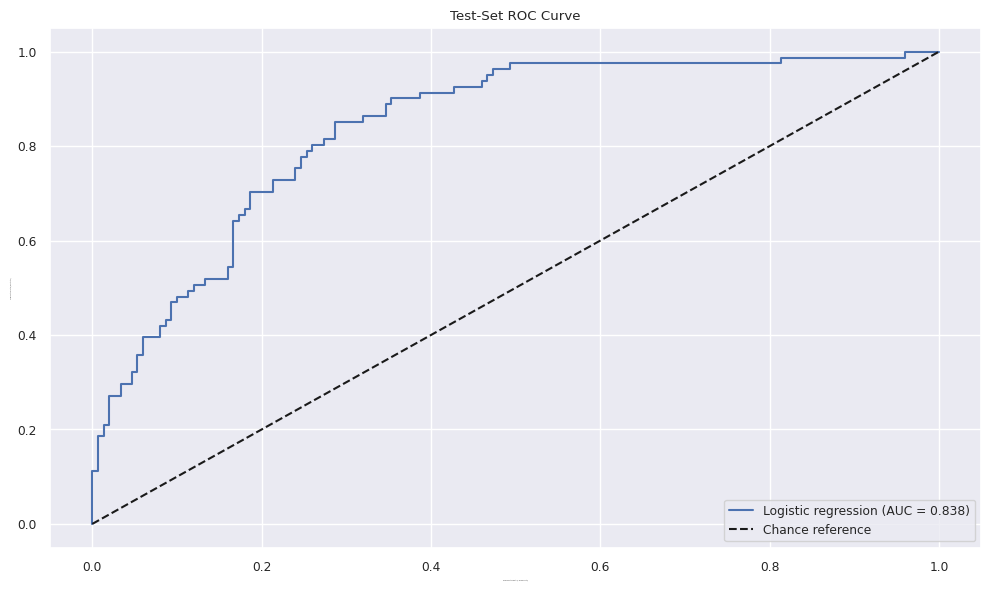

Test-set ROC AUC: 0.838


In [74]:
# @title **ROC curve and AUC for logistic regression**

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (1).
positive_index = list(logistic_pipeline.classes_).index(1)
y_probability = logistic_pipeline.predict_proba(X_test)[:, positive_index]

# Calculate test-set ROC AUC and curve.
logit_roc_auc = roc_auc_score(y_test, y_probability)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {logit_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance reference")
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Test-Set ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test-set ROC AUC: {logit_roc_auc:.3f}")

In [75]:
# @title **Select a cutoff using training-set cross-validation**

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Use the logistic_pipeline defined in the training block.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

# Each observation is predicted by a pipeline trained on other folds.
# Imputation and scaling are learned separately within each fold.
cv_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)

positive_index = list(logistic_pipeline.classes_).index(1)

fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, positive_index]
)

# Exclude the infinite threshold representing no positive predictions.
finite = np.isfinite(thresholds)
j_scores = tpr[finite] - fpr[finite]
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[finite][optimal_idx]

print(f"Selected threshold: {optimal_threshold:.3f}")
print("Criterion: maximum cross-validation sensitivity + specificity − 1.")
print("Apply this cutoff to the fitted pipeline's test-set probabilities.")

Selected threshold: 0.350
Criterion: maximum cross-validation sensitivity + specificity − 1.
Apply this cutoff to the fitted pipeline's test-set probabilities.


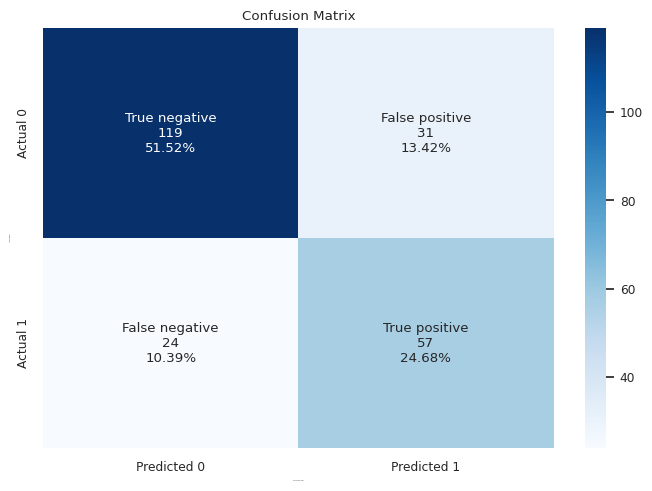

In [76]:
# @title **Make confusion matrix using the selected cutoff**

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

In [77]:
# @title **Compare training and test F1 at the selected cutoff**

from sklearn.metrics import f1_score

positive_index = list(logistic_pipeline.classes_).index(1)

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)
y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")

Selected cutoff: 0.350
Training F1: 0.688
Test F1: 0.675


## **Decision Tree**

**DECISION TREE: https://scikit-learn.org/stable/modules/tree.html#**

In [78]:
# @title **Import libraries for decision tree training and evaluation**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision tree libraries imported successfully.")

Decision tree libraries imported successfully.


In [79]:
# @title **Build and tune decision tree using cross-validation F1**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Choose the metric used for tuning.
scoring_metric = "f1"  # Alternatives: "recall", "precision", "accuracy"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

dtree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Pipeline parameters require the step name prefix.
parameters = {
    "classifier__max_depth": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [5, 10, 15],
    "classifier__max_leaf_nodes": [5, 10, 15],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

grid_obj = GridSearchCV(
    estimator=dtree_pipeline,
    param_grid=parameters,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_obj.fit(X_train, y_train)

# Already refitted on the full training set; no additional fit is needed.
dtree = grid_obj.best_estimator_

print("Decision tree pipeline built and tuned.")
print(f"Best mean cross-validation {scoring_metric}: {grid_obj.best_score_:.3f}")
print("Selected parameters:")
print(grid_obj.best_params_)

Decision tree pipeline built and tuned.
Best mean cross-validation f1: 0.676
Selected parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__max_leaf_nodes': 15, 'classifier__min_samples_leaf': 15}


In [80]:
# @title **Function to calculate accuracy, recall, precision, and F1**

from sklearn import metrics

def get_metrics_score(model, flag=True):
    """Evaluate a fitted classifier on the existing training and test sets."""

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(y_train, pred_train)
    test_acc = metrics.accuracy_score(y_test, pred_test)

    train_recall = metrics.recall_score(
        y_train, pred_train, zero_division=0
    )
    test_recall = metrics.recall_score(
        y_test, pred_test, zero_division=0
    )

    train_precision = metrics.precision_score(
        y_train, pred_train, zero_division=0
    )
    test_precision = metrics.precision_score(
        y_test, pred_test, zero_division=0
    )

    train_f1 = metrics.f1_score(y_train, pred_train, zero_division=0)
    test_f1 = metrics.f1_score(y_test, pred_test, zero_division=0)

    score_list = [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

    if flag:
        print(f"{'Metric':<12} {'Training':>10} {'Test':>10}")
        for name, train_value, test_value in [
            ("Accuracy", train_acc, test_acc),
            ("Recall", train_recall, test_recall),
            ("Precision", train_precision, test_precision),
            ("F1", train_f1, test_f1)
        ]:
            print(f"{name:<12} {train_value:>10.3f} {test_value:>10.3f}")

    return score_list

print("Metric evaluation function successfully defined.")

Metric evaluation function successfully defined.


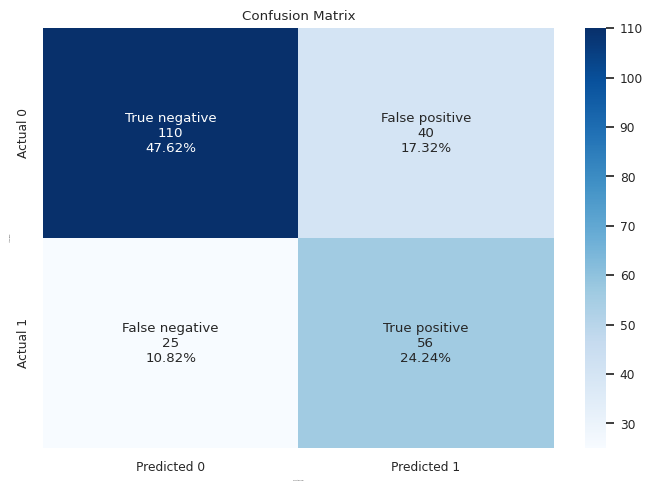

In [81]:
# @title **Display confusion matrix for the tuned decision tree**

y_pred_tree = dtree.predict(X_test)

make_confusion_matrix(y_test, y_pred_tree)

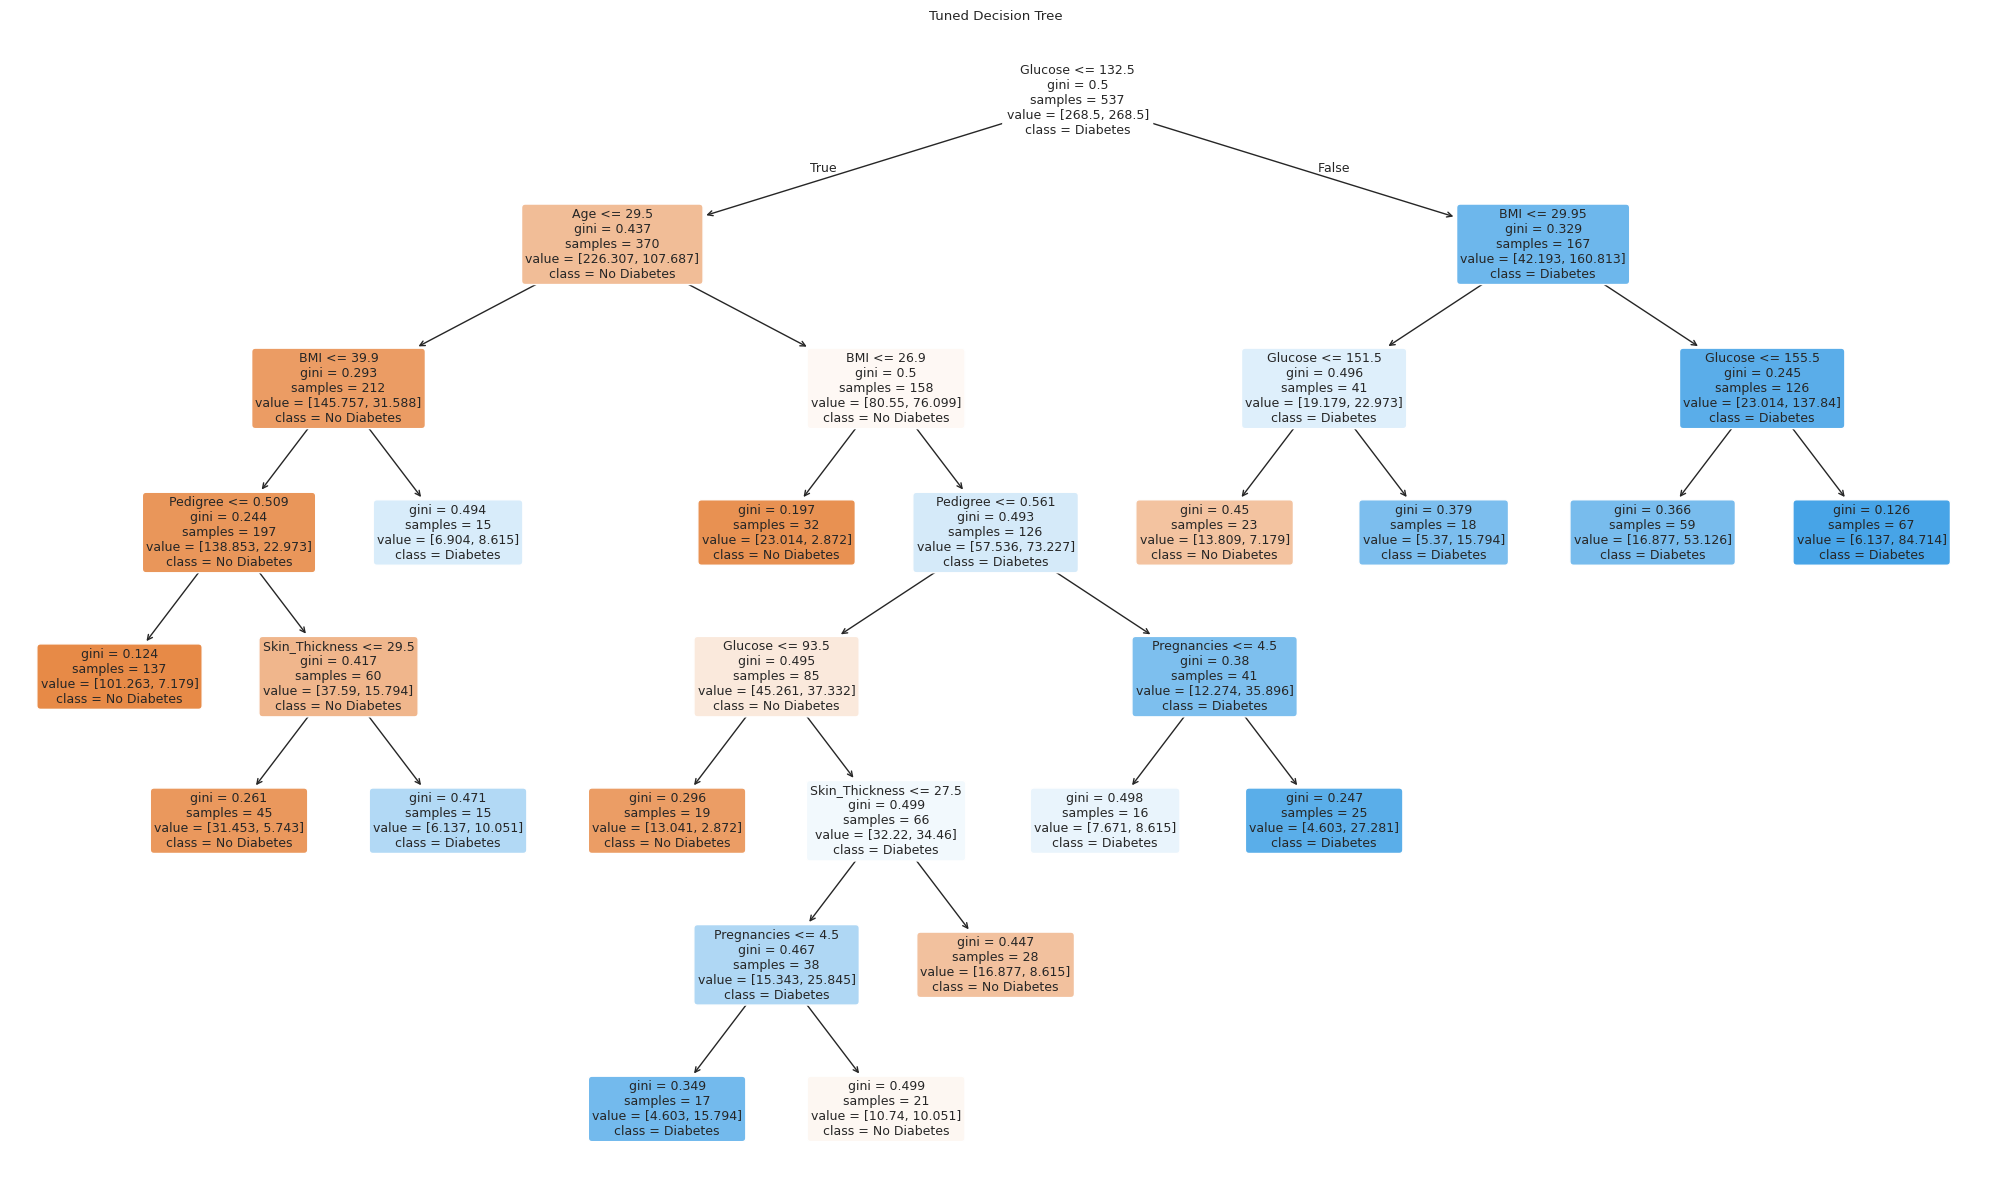

In [82]:
# @title **Show the tuned decision tree**

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    feature_names=list(feature_names),
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False
)

plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [83]:
# @title **List feature importance from the tuned decision tree**

import pandas as pd

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.reset_index(drop=True).round(3))

,Feature,Importance
0,Glucose,0.533
1,BMI,0.166
2,Age,0.130
3,Pedigree,0.075
4,Skin_Thickness,0.062
5,Pregnancies,0.033
6,D_BP,0.000
7,Insulin,0.000


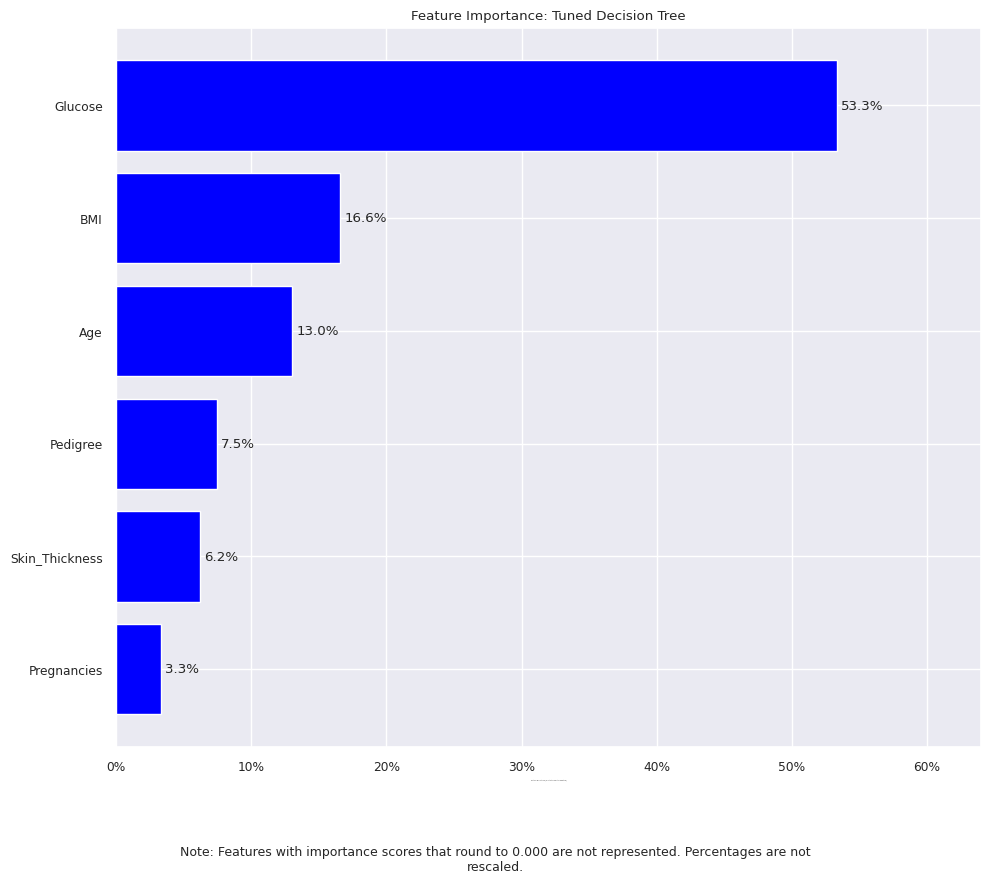

Highest-ranked features in this fitted tree:
- Glucose: 53.3%
- BMI: 16.6%
- Age: 13.0%

Excluded features (importance rounds to 0.000): D_BP, Insulin

These percentages describe each feature's share of total impurity reduction, not its effect on diabetes risk.


In [84]:
# @title **Visualize feature importance from the tuned decision tree**

import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.ticker import PercentFormatter

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()
importances = tree_classifier.feature_importances_

# Exclude scores that round to 0.000 at three decimal places.
included = np.round(importances, 3) > 0
excluded_features = feature_names[~included].tolist()

excluded_note = (
    "Excluded features (importance rounds to 0.000): "
    + ", ".join(excluded_features)
    if excluded_features
    else "No features were excluded."
)

if included.any():
    shown_names = feature_names[included]
    shown_importances = importances[included]
    indices = np.argsort(shown_importances)

    note = textwrap.fill(
        "Note: Features with importance scores that round to 0.000 "
        "are not represented. Percentages are not rescaled.",
        width=100
    )
    note_lines = len(note.splitlines())
    bottom_margin = 0.6 + 0.18 * note_lines
    figure_height = 8 + bottom_margin

    fig, ax = plt.subplots(figsize=(10, figure_height))

    bars = ax.barh(
        range(len(indices)),
        shown_importances[indices],
        color="blue"
    )

    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(shown_names[indices])
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in shown_importances[indices]],
        padding=3
    )

    ax.set_xlim(0, shown_importances.max() * 1.2)
    ax.set_xlabel("Feature Importance (% of total impurity reduction)")
    ax.set_title("Feature Importance: Tuned Decision Tree")

    fig.text(
        0.5, 0.02,
        note,
        ha="center",
        va="bottom",
        fontsize=9
    )

    plt.tight_layout(
        rect=[0, bottom_margin / figure_height, 1, 1]
    )
    plt.show()

    print("Highest-ranked features in this fitted tree:")
    for index in indices[::-1][:3]:
        print(f"- {shown_names[index]}: {shown_importances[index]:.1%}")

else:
    print("All feature importance scores round to 0.000; no graph displayed.")

print(f"\n{excluded_note}")
print(
    "\nThese percentages describe each feature's share of total "
    "impurity reduction, not its effect on diabetes risk."
)